In [1]:
import sys
from pathlib import Path

# 将项目根目录加入 Python 路径（从 notebooks 目录向上找到 multem_cgs 根目录）
_project_root = Path.cwd()
for _ in range(10):
    if (_project_root / "abTEM").exists() or (_project_root / "materials").exists():
        break
    _project_root = _project_root.parent

# 添加 abTEM Python 包所在路径
_abtem_pkg = _project_root / "abTEM"
if _abtem_pkg.exists() and (_abtem_pkg / "abtem").exists():
    _project_root = _abtem_pkg  # 指向包含 abtem/ 的目录

if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import abtem
import matplotlib.pyplot as plt
import numpy as np
from abtem.multislice import CVDMSMultislice, FourierMultislice

(examples:cbed_quickstart)=
# CBED quickstart

This notebook demonstrates a basic CBED simulation of silicon in the $(111)$ zone axis.

## Configuration

We start by (optionally) setting our configuration. See [documentation](reference:configuration) for details.

In [2]:
abtem.config.set(
    {
        "device": "gpu",
        "fft": "cupy",
        "diagnostics.task_progress": True,
        "diagnostics.progress_bar": "tqdm",
    }
);

## Atomic model
We create the atomic model. See our [walkthough](walkthrough:atomic_models) or our [tutorial](tutorials:advanced_atomic_models) on atomic models.

We fetch the crystal structure from the [Materials Project](https://materialsproject.org) database. Enter a material name to search, browse the available candidates, and pick one by index.

Material: SrTiO3
  Formula: O3SrTi
  Space group: Pm-3m (#221)
  Lattice constant: a = 3.9050 Å
  Unit cell: 5 atoms
  Cell volume: 59.55 Å³


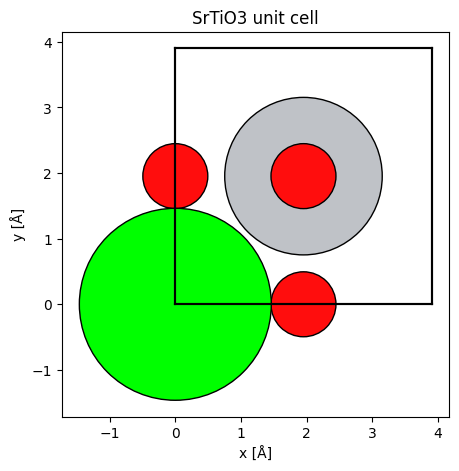

In [3]:
# ============================================================
# 晶体结构：直接使用 ASE 手动构建 SrTiO3
# ============================================================
from ase import Atoms

MATERIAL_NAME = "SrTiO3"
# SrTiO3: cubic perovskite, Pm-3m (#221), a ≈ 3.905 Å
a = 3.905
# Sr at corners, Ti at body center, O at face centers
structure = Atoms(
    symbols=["Sr", "Ti", "O", "O", "O"],
    scaled_positions=[
        [0.0, 0.0, 0.0],   # Sr
        [0.5, 0.5, 0.5],   # Ti
        [0.5, 0.5, 0.0],   # O
        [0.5, 0.0, 0.5],   # O
        [0.0, 0.5, 0.5],   # O
    ],
    cell=[a, a, a],
    pbc=True,
)

print(f"Material: {MATERIAL_NAME}")
print(f"  Formula: {structure.get_chemical_formula()}")
print(f"  Space group: Pm-3m (#221)")
print(f"  Lattice constant: a = {a:.4f} Å")
print(f"  Unit cell: {len(structure)} atoms")
print(f"  Cell volume: {structure.get_volume():.2f} Å³")

fig, ax = plt.subplots(figsize=(5, 5))
abtem.show_atoms(structure, ax=ax, title=f"{MATERIAL_NAME} unit cell")
plt.show()

Using: SrTiO3 (5 atoms, cell = 3.9050 Å)


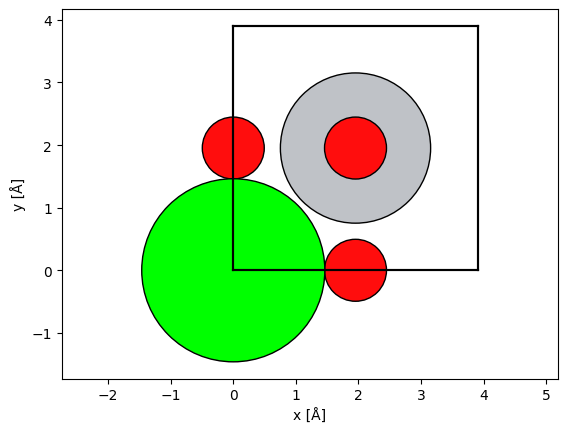

In [4]:
# structure is already set from cell above
print(f"Using: SrTiO3 ({len(structure)} atoms, cell = {structure.cell[0,0]:.4f} Å)")

abtem.show_atoms(structure, plane="xy");

We can choose the $(111)$ zone axis to be a propagation direction using the `surface` function. 

Finally we repeat the structure in $x$ and $y$, this will improve the reciprocal space resolution. We also repeat the structure in $z$, thus simulating a thicker sample.

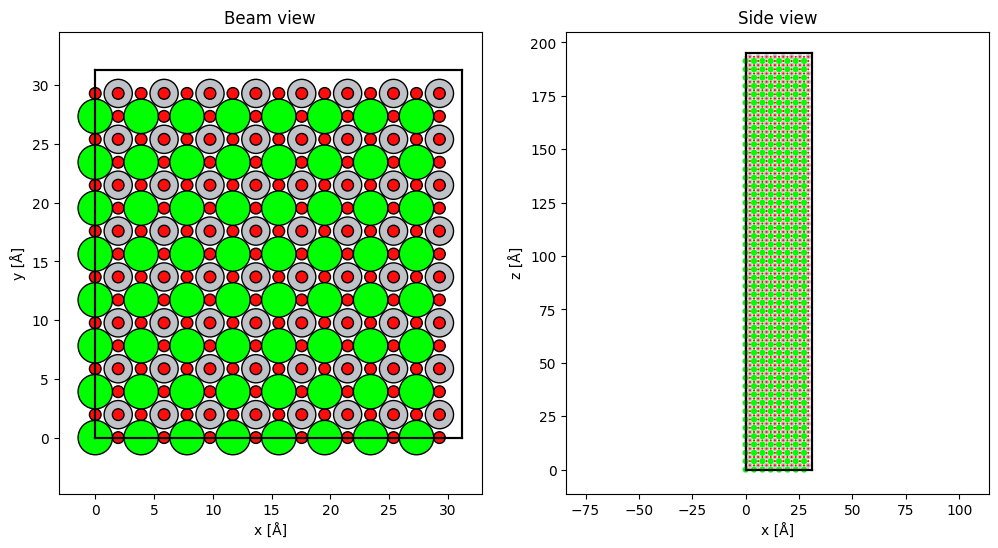

In [5]:
#structure = abtem.orthogonalize_cell(structure)
atoms = structure * (8, 8, 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
abtem.show_atoms(atoms, ax=ax1, title="Beam view")
abtem.show_atoms(atoms, ax=ax2, plane="xz", title="Side view", linewidth=0.0);

## Potential

We create an ensemble of potentials using the frozen phonon. See our [walkthrough on frozen phonons](walkthrough:frozen_phonons). 

In [6]:
frozen_phonons = abtem.FrozenPhonons(atoms, 16, {"Sr":0.164356, "Ti": 0.116584, "O": 0.148198})

We create a potential from the frozen phonons model, see [walkthrough on potentials](walkthrough:potentials).

In [7]:
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,
    projection="finite",
    slice_thickness=0.5,
    exit_planes=60,
    device="gpu",
)

total_z = atoms.cell[2, 2]
n_slices = int(np.ceil(total_z))
print(f"Thickness: {total_z:.2f} A, slices: {n_slices}")

# 采样信息
gx, gy = potential.gpts
sx, sy = potential.sampling
lx, ly = potential.extent
sz = potential.slice_thickness[0]
dkx = 1.0 / lx
dky = 1.0 / ly
dkz = 1.0 / total_z
print(f"Grid: {gx} x {gy}")
print(f"Real-space sampling: dx={sx:.4f} A, dy={sy:.4f} A, dz={sz:.4f} A")
print(f"Extent: Lx={lx:.2f} A, Ly={ly:.2f} A, Lz={total_z:.2f} A")
print(f"Reciprocal-space sampling: dkx={dkx:.6f} 1/A, dky={dky:.6f} 1/A, dkz={dkz:.6f} 1/A")
print(f"Nyquist freq: kx_max={gx*dkx/2:.4f} 1/A, ky_max={gy*dky/2:.4f} 1/A")

Thickness: 195.25 A, slices: 196
Grid: 313 x 313
Real-space sampling: dx=0.0998 A, dy=0.0998 A, dz=0.4994 A
Extent: Lx=31.24 A, Ly=31.24 A, Lz=195.25 A
Reciprocal-space sampling: dkx=0.032010 1/A, dky=0.032010 1/A, dkz=0.005122 1/A
Nyquist freq: kx_max=5.0096 1/A, ky_max=5.0096 1/A


## Wave function

We create a probe wave function at an energy of 100 keV with a convergence semiangle of $9.4 \ \mathrm{mrad}$. See our [walkthrough on wave functions](walkthrough:wave_functions). 

Partial temporal coherence is neglected here, see our [tutorial on partial coherence](tutorials:partial_coherence) if you want to include this in your simulation.

In [8]:
wave = abtem.Probe(energy=30e3, semiangle_cutoff=35)
wave.grid.match(potential)

# 保存入射波总强度用于背散射归一化
# .build() returns Waves; .array gives the CuPy/numpy array
_incident_wave_obj = wave.build()
_incident_wave_array = _incident_wave_obj.array
if hasattr(_incident_wave_array, 'get'):
    _incident_wave_array = _incident_wave_array.get()
INCIDENT_TOTAL = float((np.abs(_incident_wave_array) ** 2).sum())
del _incident_wave_obj, _incident_wave_array
print(f"Grid: {wave.gpts}, Sampling: {wave.sampling[0]:.4f} A")
print(f"Incident probe total intensity: {INCIDENT_TOTAL:.6f}")

Grid: (313, 313), Sampling: 0.0998 A
Incident probe total intensity: 0.000010


tasks:   0%|          | 0/2 [00:00<?, ?it/s]

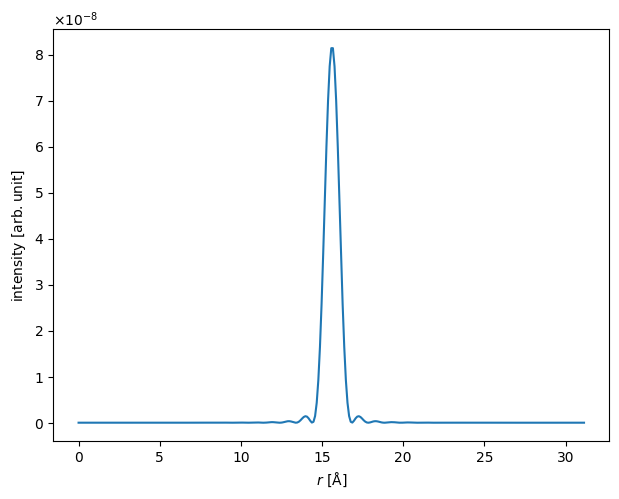

In [9]:
wave.profiles().show();

## Multislice with CVDMS

We run the multislice algorithm using the **CVDMS (Coupled-Wave Dynamical Multislice)** algorithm, which accounts for backscattering coupling between slices for higher accuracy compared to the conventional Fourier multislice method.

We configure the algorithm with explicit parameter control: order-1 expansion with backscattering corrections enabled.

In [10]:
cvdms_algorithm = CVDMSMultislice(
    convergence_threshold=1e-7,
    max_terms=50,
    max_inner=100,
    backscattering=True,         # 启用层间背散射耦合
    calculate_backscattered=True, # 计算并返回背散射波函数
    use_fused_kernel=True,
    backend="c++",              # C++ CUDA 加速路径
)

# 运行多片层模拟，同时获取前散射波和背散射波函数
_results = wave.multislice(
    potential,
    algorithm=cvdms_algorithm,
    return_backscattered=True,
)
exit_waves = _results[0]
backscattered_waves = _results[-1]

# 前散射波 → CBED 衍射图样
measurements = exit_waves.diffraction_patterns(max_angle="cutoff")


We take the mean across the frozen phonons axis, and compute the result.

In [11]:
from abtem.array import _compute

measurement = measurements.mean(0)

# 一次计算 CBED 和背散射波，共享 dask 图，multislice 只跑一次
_compute([measurement, backscattered_waves])

tasks:   0%|          | 0/99 [00:00<?, ?it/s]

[cvdms] Using C++ CUDA backend


([<abtem.measurements.DiffractionPatterns at 0x7f517d2a7b30>,
 ())

## Visualize results

We show the thickness series as an exploded plot.

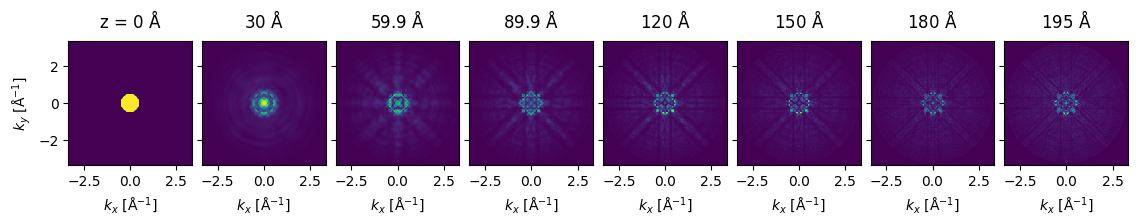

In [12]:
visualization = measurement.show(
    explode=True,
    figsize=(12, 5),
)

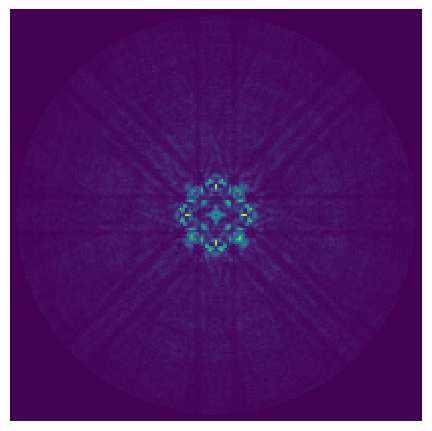

In [13]:
# this cell produces a thumbnail for the online documentation

visualization = measurement[-1].show()
visualization.axis_off()
plt.savefig("cbed_quickstart.png", bbox_inches="tight", pad_inches=0)

In [14]:
arr = measurement.array
if hasattr(arr, 'get'):
    arr = arr.get()

img = np.asarray(arr)
while img.ndim > 2:
    img = img[-1]

try:
    ang = getattr(measurement, 'angular_sampling', None)
    if ang is not None:
        ang = (float(ang[0]), float(ang[1]))
except Exception:
    ang = None

try:
    mx = getattr(measurement, 'max_angles', None)
    if mx is not None:
        mx = (float(mx[0]), float(mx[1]))
except Exception:
    mx = None

try:
    pot_gpts = getattr(potential, 'gpts', None)
except Exception:
    pot_gpts = None

print('potential shape (gpts):', pot_gpts)
print('CBED pattern shape (raw):', img.shape)
print('angular_sampling (mrad/px):', ang)
print('max_angles (mrad):', mx)

potential shape (gpts): (313, 313)
CBED pattern shape (raw): (209, 209)
angular_sampling (mrad/px): (2.234020981086563, 2.234020981086563)
max_angles (mrad): (232.33818203300257, 232.33818203300257)


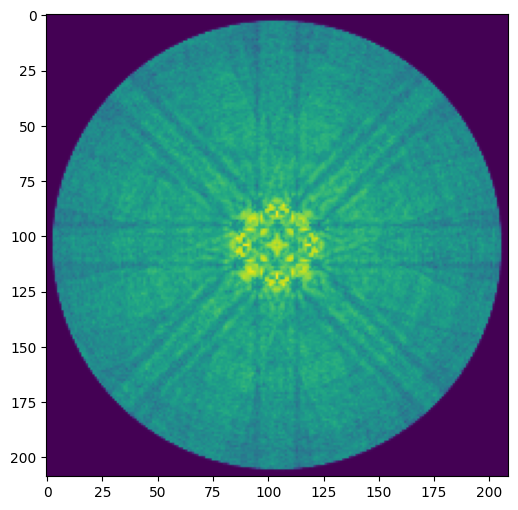

In [15]:
fix, ax = plt.subplots(1, 1, figsize=(6, 6))
# Match the notebook convention: log(transpose(last_exit_plane)).
with np.errstate(divide='ignore', invalid='ignore'):
    C = 1.5e3
    ax.imshow(np.log(1+C*img/np.max(img)), cmap="viridis")

plt.savefig("cvdms_cbed.png", dpi=300)
plt.show()

## Backscattered wave visualization

The backscattered wave functions recorded at each exit plane, after backward propagation to the top surface. This reveals the depth-dependent backscattering signal within the specimen.

Backscattered waves shape: (16, 8, 313, 313)
  dim 0: frozen phonon configs = 16
  dim 1: exit planes           = 8
  dim 2-3: spatial grid        = 313 x 313


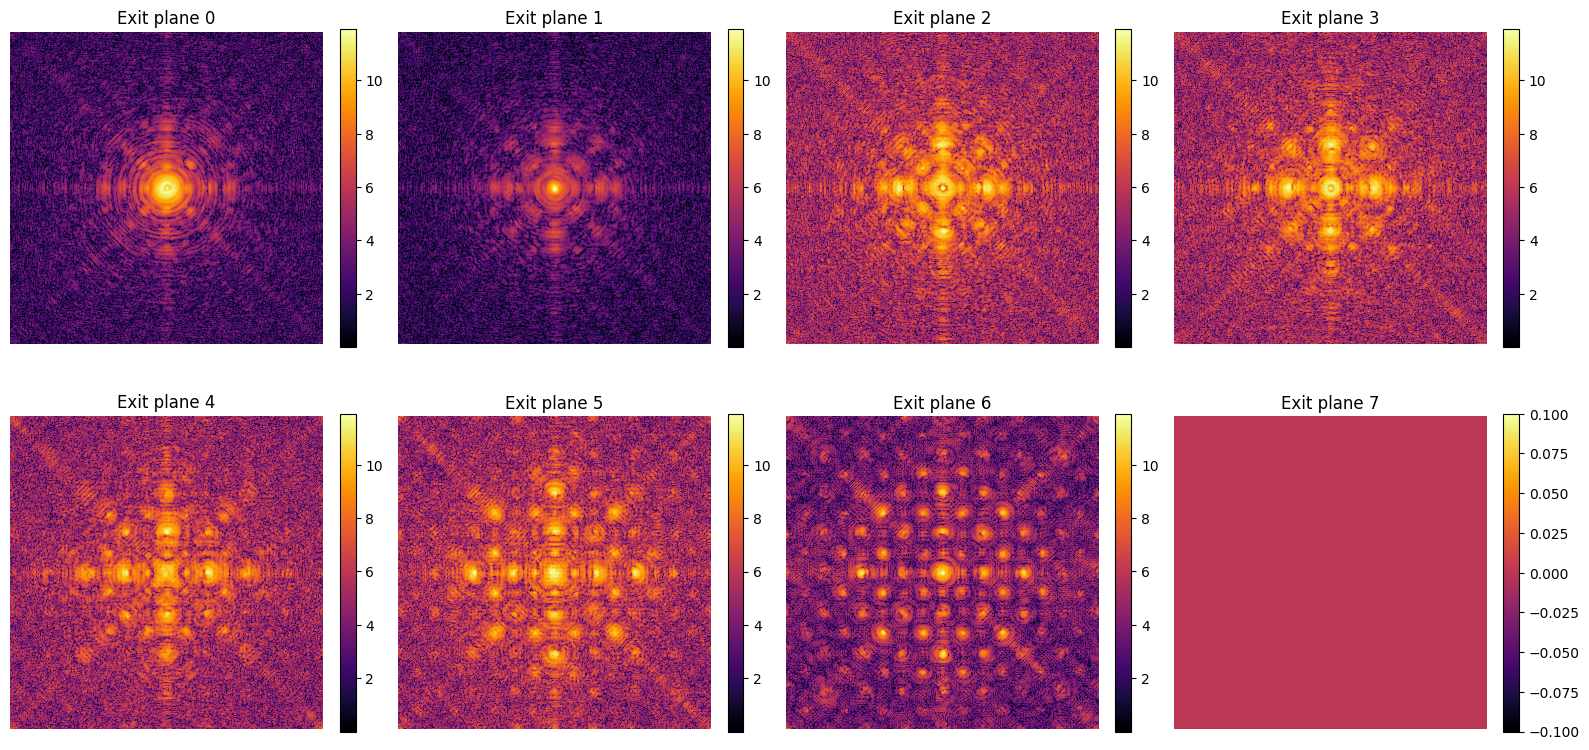

In [ ]:
# ============================================================
# 获取背散射波数据（按出口面切片）
# ============================================================
# 背散射波已由上一步的 _compute 完成计算
# 形状: (configs, exit_planes, H, W) complex64
bsc_array = backscattered_waves.array
if hasattr(bsc_array, 'get'):
    bsc_array = bsc_array.get()

print(f"Backscattered waves shape: {bsc_array.shape}")
print(f"  dim 0: frozen phonon configs = {bsc_array.shape[0]}")
print(f"  dim 1: exit planes           = {bsc_array.shape[1]}")
print(f"  dim 2-3: spatial grid        = {bsc_array.shape[2]} x {bsc_array.shape[3]}")

# 对所有 frozen phonon 取平均
bsc_mean = bsc_array.mean(axis=0)  # (exit_planes, H, W)

# 每个出口面的背散射强度
bsc_intensity = np.abs(bsc_mean) ** 2

# 显示各出口面的背散射波强度（对数尺度）
n_exit = bsc_intensity.shape[0]
n_cols = 4
n_rows = int(np.ceil(n_exit / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.ravel()

C_bsc = 1.5e5
for i in range(n_exit):
    img_i = bsc_intensity[i]
    vmax_i = np.max(img_i)
    im = axes[i].imshow(np.log(1 + C_bsc * img_i / vmax_i) if vmax_i > 0 else np.zeros_like(img_i), cmap="inferno")
    axes[i].set_title(f"Exit plane {i}")
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046)

# 隐藏多余的子图
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("backscattered_intensity.png", dpi=150, bbox_inches="tight")
plt.show()


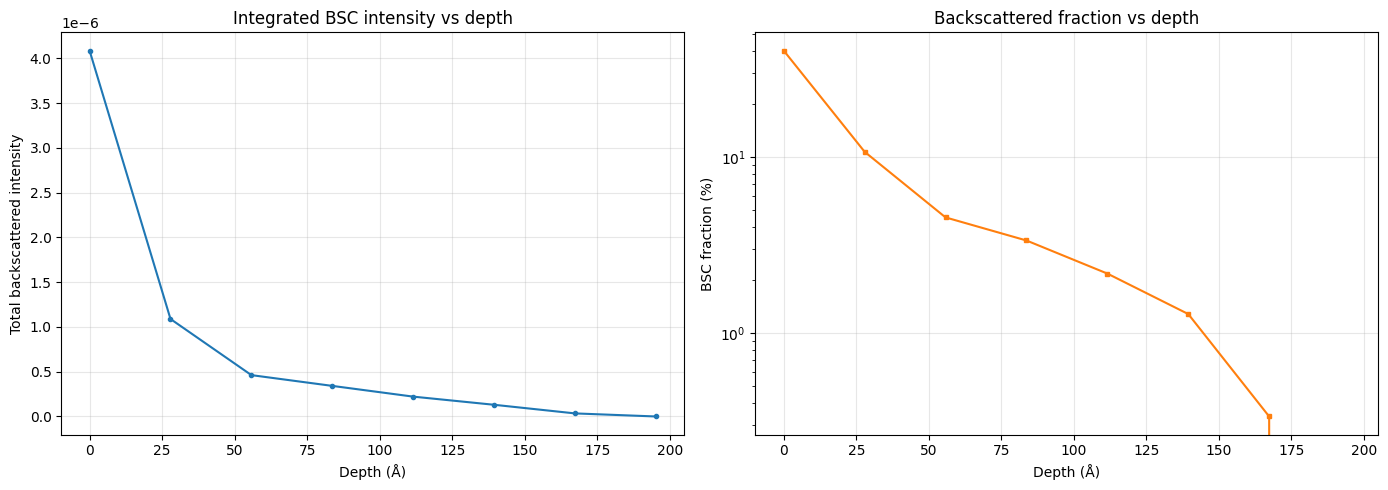

Total BSC fraction (top surface): 40.038349%


In [17]:
# ============================================================
# 背散射积分强度 vs 深度
# ============================================================
# 每个出口面总背散射强度（空间积分）
total_intensity = bsc_intensity.reshape(n_exit, -1).sum(axis=1)

# 归一化到入射波总强度（从 Probe 对象获取，非 BSC）
incident_total = INCIDENT_TOTAL
fraction = total_intensity / incident_total * 100  # 百分比

# 出口面深度 (Å)
exit_depths = np.linspace(0, total_z, n_exit)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 线性坐标
ax1.plot(exit_depths, total_intensity, "o-", markersize=3)
ax1.set_xlabel("Depth (Å)")
ax1.set_ylabel("Total backscattered intensity")
ax1.set_title("Integrated BSC intensity vs depth")
ax1.grid(True, alpha=0.3)

# 对数坐标 + 百分比
ax2.semilogy(exit_depths, fraction, "s-", markersize=3, color="C1")
ax2.set_xlabel("Depth (Å)")
ax2.set_ylabel("BSC fraction (%)")
ax2.set_title("Backscattered fraction vs depth")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bsc_fraction_depth.png", dpi=150, bbox_inches="tight")
plt.show()

# EP 0 已包含所有更深层的反向传播贡献，即总 BSC 分数
print(f"Total BSC fraction (top surface): {fraction[0]:.6f}%")
# Surface BSC fraction is already printed above as fraction[0]

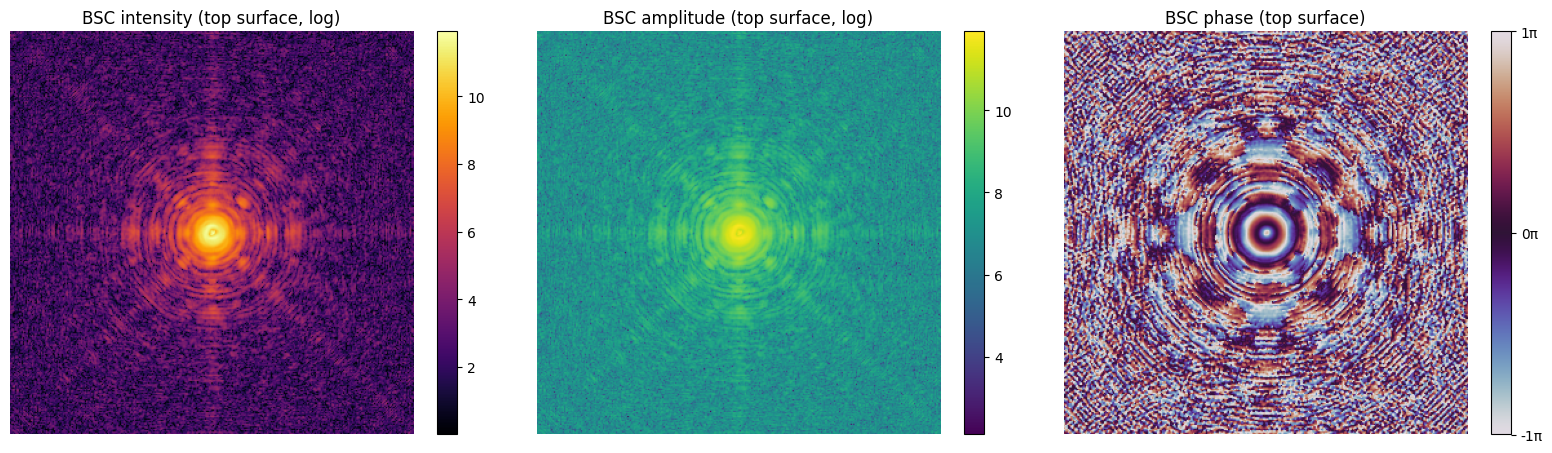

Exported: backscattered_waves.npy, backscattered_mean.npy, bsc_intensity.npy, bsc_fraction_depth.csv


In [18]:
# ============================================================
# 上表面背散射波细节 + 数据导出
# ============================================================
# 上表面 (exit plane 0) 的背散射波已包含所有深度反向传播的贡献
bsc_surface = bsc_mean[0]  # (H, W) complex

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.5))

# 强度（对数尺度）
C_bsc = 1.5e5
vmax = np.max(np.abs(bsc_surface) ** 2)
im1 = ax1.imshow(np.log(1 + C_bsc * np.abs(bsc_surface) ** 2 / vmax), cmap="inferno")
ax1.set_title("BSC intensity (top surface, log)")
ax1.axis("off")
plt.colorbar(im1, ax=ax1, fraction=0.046)

# 振幅（对数尺度）
vmax_amp = np.max(np.abs(bsc_surface))
im2 = ax2.imshow(np.log(1 + C_bsc * np.abs(bsc_surface) / vmax_amp), cmap="viridis")
ax2.set_title("BSC amplitude (top surface, log)")
ax2.axis("off")
plt.colorbar(im2, ax=ax2, fraction=0.046)

# 相位
im3 = ax3.imshow(np.angle(bsc_surface), cmap="twilight", vmin=-np.pi, vmax=np.pi)
ax3.set_title("BSC phase (top surface)")
ax3.axis("off")
plt.colorbar(im3, ax=ax3, fraction=0.046, ticks=[-np.pi, 0, np.pi],
             format=lambda x, _: f"{x / np.pi:.0f}π")

plt.tight_layout()
plt.savefig("backscattered_top_surface.png", dpi=150, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------
# 导出数据到 NPY 文件
# ----------------------------------------------------------
np.save("backscattered_waves.npy", bsc_array)      # 完整背散射波 (configs, planes, H, W)
np.save("backscattered_mean.npy", bsc_mean)         # 平均后 (planes, H, W)
np.save("bsc_intensity.npy", bsc_intensity)          # 强度 (planes, H, W)
np.savetxt("bsc_fraction_depth.csv", np.column_stack([exit_depths, fraction]),
           delimiter=",", header="depth_angstrom,bsc_fraction_pct", comments="")

print("Exported: backscattered_waves.npy, backscattered_mean.npy, bsc_intensity.npy, bsc_fraction_depth.csv")